# Dataset 

Sentiment Analysis on Iphone 16 on Amazon

In [1]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("SentimentAnalysis") \
    .getOrCreate()


25/01/06 14:53:16 WARN Utils: Your hostname, Hamzahs-iMac.local resolves to a loopback address: 127.0.0.1; using 10.142.243.111 instead (on interface en1)
25/01/06 14:53:16 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/01/06 14:53:19 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
df = spark.read.text("train.ft.txt")
df.show(truncate=False)

+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|value                                                                                                                                                                                                                                                        |
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|__label__2 The iPhone 16 is a masterpiece: The new design feels incredibly sleek, and the display quality is out of this world. The battery life is impressive, lasting me all day even with heavy use. Highly recommend it to anyone l

# Transform Dataset 

Seperate __label__ from title & reviews

In [3]:
from pyspark.sql.functions import regexp_extract
df = df.withColumn('Label', regexp_extract(df['value'], r'(__label__\d+)', 1)) \
    .withColumn('Title & Review', regexp_extract(df['value'], r'(__label__\d+)(.*)', 2))
df = df.drop('value')
df.show(truncate=False)

+----------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|Label     |Title & Review                                                                                                                                                                                                                                     |
+----------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|__label__2| The iPhone 16 is a masterpiece: The new design feels incredibly sleek, and the display quality is out of this world. The battery life is impressive, lasting me all day even with heavy use. Highly recommend it to anyo

Seperate Dataset even further by making a title column and Review

In [4]:
from pyspark.sql.functions import split, expr
df = df.withColumn('Title', split(df['Title & Review'], ':', 2).getItem(0)) \
    .withColumn('Review', expr("substring_index(`Title & Review`, ':', -1)"))
df = df.drop('Title & Review')
df.show(truncate=False)

+----------+-------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|Label     |Title                          |Review                                                                                                                                                                                                             |
+----------+-------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|__label__2| The iPhone 16 is a masterpiece| The new design feels incredibly sleek, and the display quality is out of this world. The battery life is impressive, lasting me all day even with heavy use. Highly recommend it to anyo

Lets transform label to 'Actual Review' instead of having to use __label__1 and __label__2 

In [5]:
from pyspark.sql.functions import when
df = df.withColumn('Actual Review', when(df['Label'] == '__label__1', 'NEGATIVE').otherwise('POSITIVE'))
df = df.drop('Label')

Lets add an ID column

In [6]:
from pyspark.sql.functions import monotonically_increasing_id
df = df.withColumn("ID", monotonically_increasing_id())
df = df.select("ID", "Actual Review", "Title", "Review")
df.show(truncate=False)

+---+-------------+-------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|ID |Actual Review|Title                          |Review                                                                                                                                                                                                             |
+---+-------------+-------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|0  |POSITIVE     | The iPhone 16 is a masterpiece| The new design feels incredibly sleek, and the display quality is out of this world. The battery life is impressive, lasting me all day even with heavy use.

In [7]:
num_rows = df.count()
num_cols = len(df.columns)
print(f"DataFrame shape: ({num_rows}, {num_cols})")

DataFrame shape: (3600054, 4)


Lets explain what "__label__1" and so on means:
- __label__1 means 1 to 2 star review -----> Negative
- __label__2 means 4 to 5 star review -----> Positive

__There is no neutral in this dataset__


# Preproccessing
Drop Duplicates

In [8]:
df = df.dropDuplicates()

Drop Nulls

In [9]:
df = df.dropna(how='any')

In [10]:
num_rows = df.count()
num_cols = len(df.columns)
print(f"DataFrame shape: ({num_rows}, {num_cols})")

25/01/06 14:54:10 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 14:54:10 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 14:54:10 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 14:54:10 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 14:54:10 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 14:54:10 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 14:54:13 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 14:54:13 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 14:54:13 WARN RowBasedKeyValueBatch: Calling spill() on

DataFrame shape: (3600054, 4)


# Partitioning

In [11]:
partition_df = df.repartition(100)


# Sentiment Analysis

Pre-Trained Models

 - Load 'Sentiment-Analysis' pretrained model

In [12]:
from transformers import pipeline
sentiment_pipeline = pipeline('sentiment-analysis')

/Users/hamoaster/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
2025-01-06 14:54:53.098178: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/hamoaster/Library/Python/3.9/lib/python/site-packages/threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible wo

 - Function to predict sentiment

In [13]:
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType
def get_sentiment(post):
    result = sentiment_pipeline(post)[0]
    return result['label']

- Use the function to predict using 'Post' collumn and create a new collumn named 'Sentiment-Prediction' to store the results

In [14]:
sentiment_udf = udf(get_sentiment, StringType())
partition_df = partition_df.withColumn('Sentiment-Prediction', sentiment_udf(train_df['Review']))

Lets evaluate the model using the accuracy
 - View in detail from the table

In [ ]:
from pyspark.sql.functions import col, when
partition_df = partition_df.withColumn('Corresponds', when(col('Actual Review') == col('Sentiment-Prediction'), '1').otherwise('0'))

25/01/06 14:55:38 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 14:55:38 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 14:55:38 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 14:55:38 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 14:55:38 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 14:55:38 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 14:55:38 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 14:55:38 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 14:55:38 WARN RowBasedKeyValueBatch: Calling spill() on

+-------------+--------------------+-----------+
|Actual Review|Sentiment-Prediction|Corresponds|
+-------------+--------------------+-----------+
|NEGATIVE     |NEGATIVE            |1          |
|NEGATIVE     |NEGATIVE            |1          |
|POSITIVE     |POSITIVE            |1          |
|NEGATIVE     |NEGATIVE            |1          |
|NEGATIVE     |NEGATIVE            |1          |
|NEGATIVE     |POSITIVE            |0          |
|NEGATIVE     |NEGATIVE            |1          |
|NEGATIVE     |NEGATIVE            |1          |
|POSITIVE     |POSITIVE            |1          |
|POSITIVE     |POSITIVE            |1          |
|NEGATIVE     |NEGATIVE            |1          |
|NEGATIVE     |NEGATIVE            |1          |
|NEGATIVE     |NEGATIVE            |1          |
|POSITIVE     |POSITIVE            |1          |
|NEGATIVE     |NEGATIVE            |1          |
|NEGATIVE     |NEGATIVE            |1          |
|NEGATIVE     |POSITIVE            |0          |
|NEGATIVE     |NEGAT

- Calculate accuracy 

In [16]:
trimmed_df = partition_df.limit(200)

Now lets calculate accuracy

In [17]:
total_count = trimmed_df.count()
correct_predictions = trimmed_df.filter(test_df['Corresponds'] == '1').count()
accuracy = correct_predictions / total_count
print(f"Accuracy: {accuracy:.2%}")

25/01/06 14:56:50 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 14:56:50 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 14:56:50 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 14:56:50 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 14:56:50 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 14:56:50 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 14:56:50 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 14:56:50 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 14:56:50 WARN RowBasedKeyValueBatch: Calling spill() on

Accuracy: 92.00%


Now lets try a different model that predicts emotions (DistilRoBetA)

 - Download and load model

In [18]:
emotion_pipeline = pipeline('text-classification', model='j-hartmann/emotion-english-distilroberta-base', return_all_scores=False)

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.
/Users/hamoaster/Library/Python/3.9/lib/python/site-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


 - Function to predict and use the model

In [19]:
def get_emotion(post):
    result = emotion_pipeline(post)[0]
    return result['label']

- Use the function to predict from collumn 'Post' and store results in 'Emotion-Prediction'

In [20]:
emotion_udf = udf(get_emotion, StringType())
df = df.withColumn('Emotion-Prediction', emotion_udf(df['Review']))

 - Save results

In [21]:
df = df.withColumn('Emotion-Prediction', emotion_udf(df['Review']))

 - Display Emotion-Prediction and Post

In [22]:
df.select('Actual Review','Emotion-Prediction').show(truncate=False)

25/01/06 15:10:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:10:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:10:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:10:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:10:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:10:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:10:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:10:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:10:19 WARN RowBasedKeyValueBatch: Calling spill() on

+-------------+------------------+
|Actual Review|Emotion-Prediction|
+-------------+------------------+
|POSITIVE     |joy               |
|POSITIVE     |neutral           |
|NEGATIVE     |neutral           |
|POSITIVE     |joy               |
|POSITIVE     |joy               |
|POSITIVE     |joy               |
|NEGATIVE     |fear              |
|POSITIVE     |joy               |
|NEGATIVE     |sadness           |
|POSITIVE     |neutral           |
|NEGATIVE     |disgust           |
|POSITIVE     |anger             |
|NEGATIVE     |disgust           |
|POSITIVE     |surprise          |
|NEGATIVE     |sadness           |
|NEGATIVE     |neutral           |
|POSITIVE     |neutral           |
|NEGATIVE     |disgust           |
|NEGATIVE     |disgust           |
|NEGATIVE     |surprise          |
+-------------+------------------+
only showing top 20 rows



# Visualisation

Bar chart for Actual Reviews

25/01/06 15:10:52 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:10:52 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:10:52 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:10:52 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:10:52 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:10:52 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:10:52 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:10:52 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:10:52 WARN RowBasedKeyValueBatch: Calling spill() on

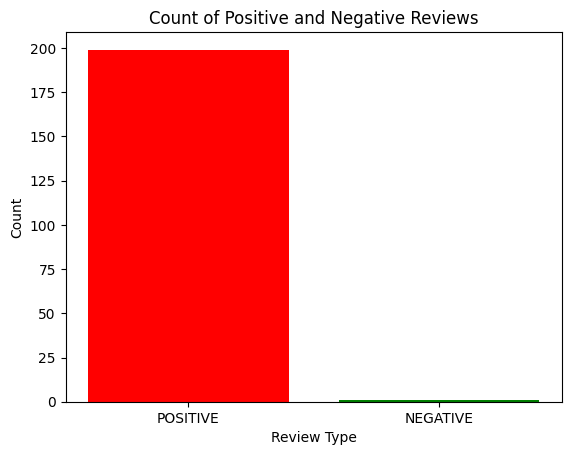

In [ ]:
import matplotlib.pyplot as plt
review_counts = trimmed_df.groupBy('Actual Review').count().collect()
review_counts_dict = {row['Actual Review']: row['count'] for row in review_counts}
labels = list(review_counts_dict.keys())
counts = list(review_counts_dict.values())

plt.bar(labels, counts, color=['red', 'green'])
plt.xlabel('Review Type')
plt.ylabel('Count')
plt.title('Count of Positive and Negative Reviews')
plt.show()

Bar chart for predicted sentiment

25/01/06 15:13:13 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:13:13 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:13:13 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:13:13 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:13:13 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:13:13 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:13:13 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:13:13 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:13:13 WARN RowBasedKeyValueBatch: Calling spill() on

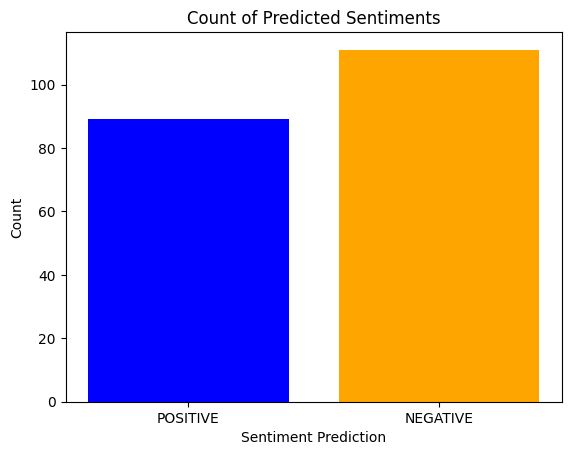

In [24]:
sentiment_counts = trimmed_df.groupBy('Sentiment-Prediction').count().collect()
sentiment_counts_dict = {row['Sentiment-Prediction']: row['count'] for row in sentiment_counts}
labels = list(sentiment_counts_dict.keys())
counts = list(sentiment_counts_dict.values())

plt.bar(labels, counts, color=['blue', 'orange'])
plt.xlabel('Sentiment Prediction')
plt.ylabel('Count')
plt.title('Count of Predicted Sentiments')
plt.show()

Comparison

25/01/06 15:26:05 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:26:05 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:26:05 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:26:05 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:26:05 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:26:05 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:26:05 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:26:05 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 15:26:05 WARN RowBasedKeyValueBatch: Calling spill() on

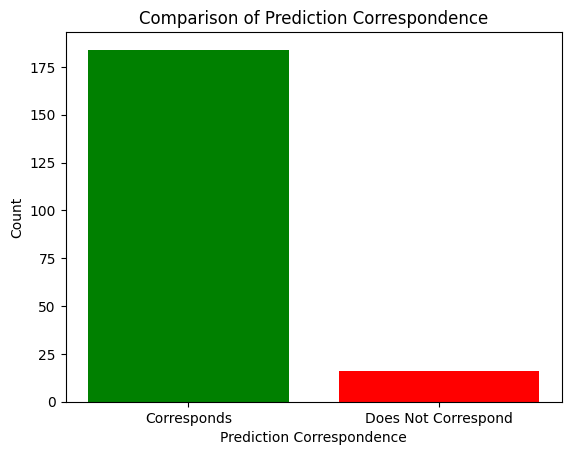

In [25]:
corresponds_counts = trimmed_df.groupBy('Corresponds').count().collect()
corresponds_counts_dict = {row['Corresponds']: row['count'] for row in corresponds_counts}
labels = ['Corresponds', 'Does Not Correspond']
counts = [corresponds_counts_dict.get('1', 0), corresponds_counts_dict.get('0', 0)]

plt.bar(labels, counts, color=['green', 'red'])
plt.xlabel('Prediction Correspondence')
plt.ylabel('Count')
plt.title('Comparison of Prediction Correspondence')
plt.show()


Emotion 

25/01/06 16:01:55 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 16:01:55 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 16:01:55 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 16:01:55 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 16:01:55 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 16:01:55 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 16:01:55 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 16:01:55 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/01/06 16:01:55 WARN RowBasedKeyValueBatch: Calling spill() on

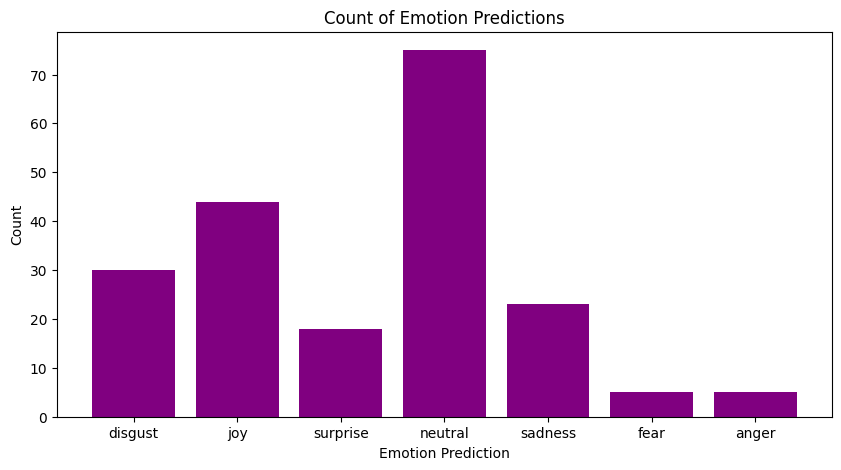

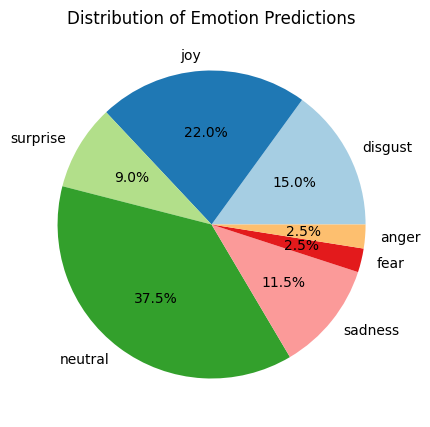

In [27]:
trimmed_df = trimmed_df.withColumn('Emotion-Prediction', emotion_udf(trimmed_df['Review']))

emotion_counts = trimmed_df.groupBy('Emotion-Prediction').count().collect()
emotion_counts_dict = {row['Emotion-Prediction']: row['count'] for row in emotion_counts}
labels = list(emotion_counts_dict.keys())
counts = list(emotion_counts_dict.values())

plt.figure(figsize=(10, 5))
plt.bar(labels, counts, color='purple')
plt.xlabel('Emotion Prediction')
plt.ylabel('Count')
plt.title('Count of Emotion Predictions')
plt.show()

plt.figure(figsize=(10, 5))
plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=plt.cm.Paired.colors)
plt.title('Distribution of Emotion Predictions')
plt.show()